In [26]:
import os
import joblib
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix, 
    ConfusionMatrixDisplay,
    RocCurveDisplay,

)

from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


import mlflow
import mlflow.sklearn
import mlflow.lightgbm
import mlflow.catboost

### Data Import

In [27]:
PROJECT_ROOT = Path("../")

DATA_PATH = (
    PROJECT_ROOT /
    "data" /
    "features" /
    "customer_churn_dataset.csv"
)


customers_ml = pd.read_csv(DATA_PATH)

customers_ml.head()

,frequency,monetary,avg_order_value,frequency.1,unique_categories,unique_sellers,avg_review_score,late_delivery_ratio,avg_installments,max_installments,payment_method_count,preferred_payment_type,state,latitude,longitude,churn_label
0,2,82.82,41.41,2,2,2,4.5,0.0,1.0,1.0,1,credit_card,SP,-23.577482,-46.587077,1
1,1,141.46,141.46,1,1,1,4.0,0.0,1.0,1.0,1,boleto,BA,-12.186877,-44.540232,0
2,1,179.12,179.12,1,1,1,5.0,0.0,3.0,3.0,1,credit_card,GO,-16.745150,-48.514783,0
3,1,72.20,72.20,1,1,1,5.0,0.0,1.0,1.0,1,credit_card,RN,-5.774002,-35.270976,1
4,1,28.62,28.62,1,1,1,5.0,0.0,1.0,1.0,1,credit_card,SP,-23.676257,-46.514580,0


In [28]:
customers_ml.shape

(96096, 16)

### Train Test Split

In [29]:
X = customers_ml.drop(columns=["churn_label"])

y = customers_ml["churn_label"]

In [30]:
X.value_counts()

frequency  monetary  avg_order_value  frequency.1  unique_categories  unique_sellers  avg_review_score  late_delivery_ratio  avg_installments  max_installments  payment_method_count  preferred_payment_type  state  latitude    longitude 
1          82.98     82.980000        1            1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             SP     -23.604706  -46.693332    3
           42.27     42.270000        1            1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             RN     -5.887088   -35.207494    3
           65.00     65.000000        1            1                  1               5.000000          0.000000             1.000000          1.0               1                     credit_card             PR     -25.434017  -49.297219    2
           0.00      0.000000        

In [31]:
y.value_counts()

churn_label
0    51251
1    44845
Name: count, dtype: int64

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [33]:
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (76876, 15)
Test set shape: (19220, 15)


### Create Shared Preprocessing Components
- Uses **SimpleImputer** library

In [34]:
print("Categorical features:")
categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()
print(categorical_features)

print("\nNumerical features:")
numeric_features = X.select_dtypes(
    exclude="object"
).columns.tolist()
print(numeric_features)




Categorical features:
['preferred_payment_type', 'state']

Numerical features:
['frequency', 'monetary', 'avg_order_value', 'frequency.1', 'unique_categories', 'unique_sellers', 'avg_review_score', 'late_delivery_ratio', 'avg_installments', 'max_installments', 'payment_method_count', 'latitude', 'longitude']


#### Numerical Imputation

In [35]:
# Missing value imputation for numerical features
numeric_imputer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"  # Use median
            )
        )
    ]
)

#### Categorical One-Hot Encoding

In [36]:
# Missing value imputation for categorical features
categorical_encoder = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"   # Use mode
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"   # Ignore unknown categories during transformation when deployment
            )
        )
    ]
)

In [41]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_imputer,
            numeric_features
        ),
        (
            "categorical",
            categorical_encoder,
            categorical_features
        )
    ],
    remainder="drop"
)

In [42]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed testing shape:", X_test_processed.shape)

Processed training shape: (76876, 47)
Processed testing shape: (19220, 47)


### Model Evaluation Function

In [37]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)  # Returns the final class

    probabilities = model.predict_proba(X_test)[:, 1]  # Returns probabilities for the 
                                                       # positive class (churn)

    metrics = {
        "accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "precision": precision_score(
            y_test,
            predictions
        ),

        "recall": recall_score(
            y_test,
            predictions
        ),

        "f1_score": f1_score(
            y_test,
            predictions
        ),

        "roc_auc": roc_auc_score(
            y_test,
            probabilities
        )
    }

    return metrics

### Cross-Validation Strategy

In [38]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### MLFlow Setup

In [39]:
PROJECT_ROOT = Path("../").resolve()

mlflow.set_tracking_uri(
    f"sqlite:///{PROJECT_ROOT / 'mlflow.db'}"
)

mlflow.set_experiment("Ecom_Customer_Churn_Tuning")

print("MLflow Tracking URI:", mlflow.get_tracking_uri())

MLflow Tracking URI: sqlite:///C:\Users\cjc72\Desktop\e-commerce-ai-ml-retention-platform\e-commerce-ai-ml-retention-platform\mlflow.db


### Model Tuning
#### LightGBM

In [46]:
# Define base model
lgbm = LGBMClassifier(
    objective="binary",
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Define pipeline
lgbm_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            lgbm
        )
    ]
)

# Define search space
lgbm_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__num_leaves": [15, 31, 63, 127],
    "model__max_depth": [-1, 5, 10, 15],
    "model__min_child_samples": [10, 20, 30, 50, 100],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__reg_alpha": [0, 0.01, 0.1, 1],
    "model__reg_lambda": [0, 0.01, 0.1, 1]
}

In [47]:
with mlflow.start_run(run_name="lightgbm_tuning") as run:
    search_lgbm = RandomizedSearchCV(
        estimator=lgbm_pipeline,
        param_distributions=lgbm_param_grid,
        n_iter=30,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search_lgbm.fit(X_train, y_train)

    best_lgbm = search_lgbm.best_estimator_

    test_metrics = evaluate_model(
        best_lgbm,
        X_test,
        y_test
    )

    mlflow.log_params(search_lgbm.best_params_)
    mlflow.log_metric("cv_best_f1", search_lgbm.best_score_)

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            metric_value
        )

    mlflow.sklearn.log_model(
        best_lgbm,
        "model",
        serialization_format="pickle"
    )

    print("Best LightGBM parameters:")
    print(search_lgbm.best_params_)

    print("\nBest cross-validation F1:")
    print(search_lgbm.best_score_)


    print("\nTest metrics:")
    print(test_metrics)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/08/09 13:26:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/09 13:26:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best LightGBM parameters:
{'model__subsample': 1.0, 'model__reg_lambda': 0, 'model__reg_alpha': 1, 'model__num_leaves': 63, 'model__n_estimators': 200, 'model__min_child_samples': 50, 'model__max_depth': -1, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

Best cross-validation F1:
0.5129067254949986

Test metrics:
{'accuracy': 0.5906347554630593, 'precision': 0.5765966328092389, 'recall': 0.46203590143828743, 'f1_score': 0.512998266897747, 'roc_auc': 0.6231706858269956}


#### CatBoost

In [48]:
# Define base model
catboost = CatBoostClassifier(
    loss_function="Logloss",
    eval_metric="F1",
    random_seed=42,
    verbose=False,
    thread_count=-1
)

# Define pipeline
catboost_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            catboost
        )
    ]
)

# Define search space
catboost_param_grid = {
    "model__iterations": [100, 200, 300, 500],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__depth": [4, 5, 6, 7, 8, 10],
    "model__l2_leaf_reg": [1, 3, 5, 10],
    "model__subsample": [0.7, 0.8, 0.9, 1.0]
}

In [49]:
with mlflow.start_run(run_name="catboost_tuning") as run:
    search_catboost = RandomizedSearchCV(
        estimator=catboost_pipeline,
        param_distributions=catboost_param_grid,
        n_iter=30,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search_catboost.fit(X_train, y_train)

    best_catboost = search_catboost.best_estimator_

    test_metrics = evaluate_model(
        best_catboost,
        X_test,
        y_test
    )

    mlflow.log_params(search_catboost.best_params_)
    mlflow.log_metric(
        "cv_best_f1",
        search_catboost.best_score_
    )

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            metric_value
        )

    mlflow.sklearn.log_model(
        best_catboost,
        "model",
        serialization_format="pickle"
    )

    print("Best CatBoost parameters:")
    print(search_catboost.best_params_)

    print("\nBest cross-validation F1:")
    print(search_catboost.best_score_)

    print("\nTest metrics:")
    print(test_metrics)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/08/09 13:39:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/09 13:39:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best CatBoost parameters:
{'model__subsample': 1.0, 'model__learning_rate': 0.1, 'model__l2_leaf_reg': 1, 'model__iterations': 500, 'model__depth': 10}

Best cross-validation F1:
0.5034517447531067

Test metrics:
{'accuracy': 0.5822060353798127, 'precision': 0.5637994292702813, 'recall': 0.4625933771880923, 'f1_score': 0.5082067613914748, 'roc_auc': 0.6136730142766542}


#### Random Forest

In [52]:
# Define base model
random_forest = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# Define pipeline
rf_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            random_forest
        )
    ]
)

# Define search space
rf_param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 5, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 5, 10],
    "model__max_features": ["sqrt", "log2", None],
    "model__class_weight": [None, "balanced"]
}

In [53]:
with mlflow.start_run(run_name="random_forest_tuning") as run:
    search_rf = RandomizedSearchCV(
        estimator=rf_pipeline,
        param_distributions=rf_param_grid,
        n_iter=30,
        scoring="f1",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    search_rf.fit(X_train, y_train)

    best_rf = search_rf.best_estimator_

    test_metrics = evaluate_model(
        best_rf,
        X_test,
        y_test
    )

    mlflow.log_params(search_rf.best_params_)
    mlflow.log_metric(
        "cv_best_f1",
        search_rf.best_score_
    )

    for metric_name, metric_value in test_metrics.items():
        mlflow.log_metric(
            f"test_{metric_name}",
            metric_value
        )

    mlflow.sklearn.log_model(
        best_rf,
        "model",
        serialization_format="pickle"
    )

    print("Best Random Forest parameters:")
    print(search_rf.best_params_)

    print("\nBest cross-validation F1:")
    print(search_rf.best_score_)

    print("\nTest metrics:")
    print(test_metrics)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


2026/08/09 14:31:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/09 14:31:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Best Random Forest parameters:
{'model__n_estimators': 100, 'model__min_samples_split': 20, 'model__min_samples_leaf': 5, 'model__max_features': None, 'model__max_depth': 20, 'model__class_weight': 'balanced'}

Best cross-validation F1:
0.5606233216646542

Test metrics:
{'accuracy': 0.5935483870967742, 'precision': 0.564499944252425, 'recall': 0.564499944252425, 'f1_score': 0.564499944252425, 'roc_auc': 0.6269996159176441}


### Tuned Model Comparison

In [54]:
tuned_models = {
    "LightGBM": best_lgbm,
    "CatBoost": best_catboost,
    "Random Forest": best_rf
}

tuned_results = []

for model_name, model in tuned_models.items():
    metrics = evaluate_model(
        model,
        X_test,
        y_test
    )

    metrics["model"] = model_name
    tuned_results.append(metrics)

tuned_results = pd.DataFrame(tuned_results)

tuned_results = tuned_results[
    [
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
].sort_values(
    "f1_score",
    ascending=False
)

tuned_results

,model,accuracy,precision,recall,f1_score,roc_auc
2,Random Forest,0.593548,0.564500,0.564500,0.564500,0.627000
0,LightGBM,0.590635,0.576597,0.462036,0.512998,0.623171
1,CatBoost,0.582206,0.563799,0.462593,0.508207,0.613673


### Base vs Tuned

In [55]:
baseline_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "accuracy": 0.542924037,
        "f1_score": 0.540509440,
        "precision": 0.509064039,
        "recall": 0.576095439,
        "roc_auc": 0.567307237
    },
    {
        "model": "Random Forest",
        "accuracy": 0.556399583,
        "f1_score": 0.521870794,
        "precision": 0.524991537,
        "recall": 0.518786932,
        "roc_auc": 0.580511527
    },
    {
        "model": "LightGBM",
        "accuracy": 0.584131113,
        "f1_score": 0.564912089,
        "precision": 0.551903850,
        "recall": 0.578548333,
        "roc_auc": 0.616755510
    },
    {
        "model": "CatBoost",
        "accuracy": 0.568158168,
        "f1_score": 0.552801724,
        "precision": 0.534876446,
        "recall": 0.571970119,
        "roc_auc": 0.598292725
    }
])

baseline_results["stage"] = "Baseline"
tuned_results["stage"] = "Tuned"

comparison_results = pd.concat(
    [baseline_results, tuned_results],
    ignore_index=True
)

comparison_results = comparison_results[
    [
        "stage",
        "model",
        "accuracy",
        "precision",
        "recall",
        "f1_score",
        "roc_auc"
    ]
]

comparison_results.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
)

,stage,model,accuracy,precision,recall,f1_score,roc_auc
2,Baseline,LightGBM,0.584131,0.551904,0.578548,0.564912,0.616756
4,Tuned,Random Forest,0.593548,0.564500,0.564500,0.564500,0.627000
3,Baseline,CatBoost,0.568158,0.534876,0.571970,0.552802,0.598293
0,Baseline,Logistic Regression,0.542924,0.509064,0.576095,0.540509,0.567307
1,Baseline,Random Forest,0.556400,0.524992,0.518787,0.521871,0.580512
5,Tuned,LightGBM,0.590635,0.576597,0.462036,0.512998,0.623171
6,Tuned,CatBoost,0.582206,0.563799,0.462593,0.508207,0.613673


### Model Performance Visualization

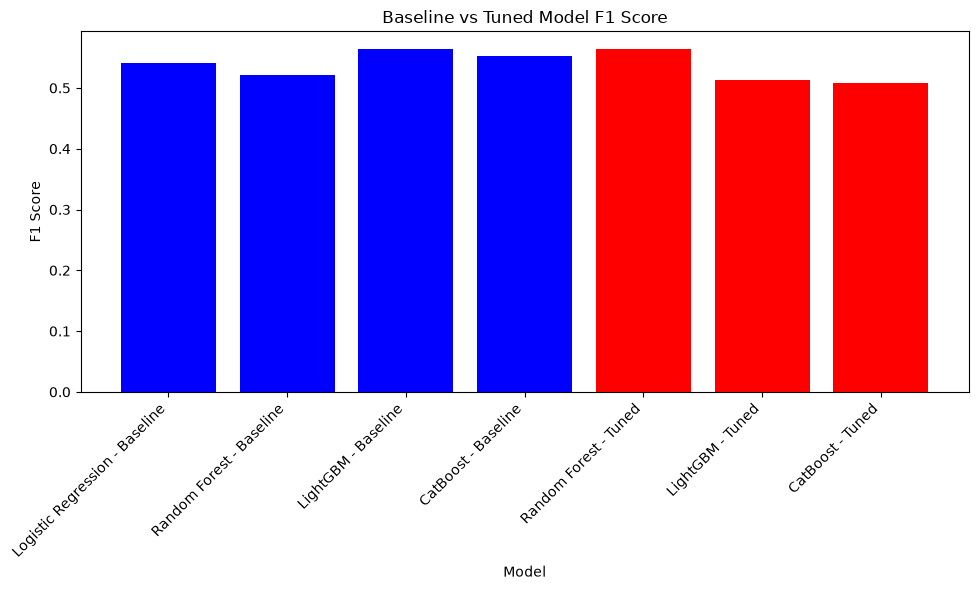

In [60]:
plt.figure(figsize=(10, 6))

comparison_results["label"] = (
    comparison_results["model"]
    + " - "
    + comparison_results["stage"]
)

colors = comparison_results["stage"].map({
    "Baseline": "blue",
    "Tuned": "red"
})

plt.bar(
    comparison_results["label"],
    comparison_results["f1_score"],
    color=colors
)

plt.ylabel("F1 Score")
plt.xlabel("Model")
plt.title("Baseline vs Tuned Model F1 Score")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

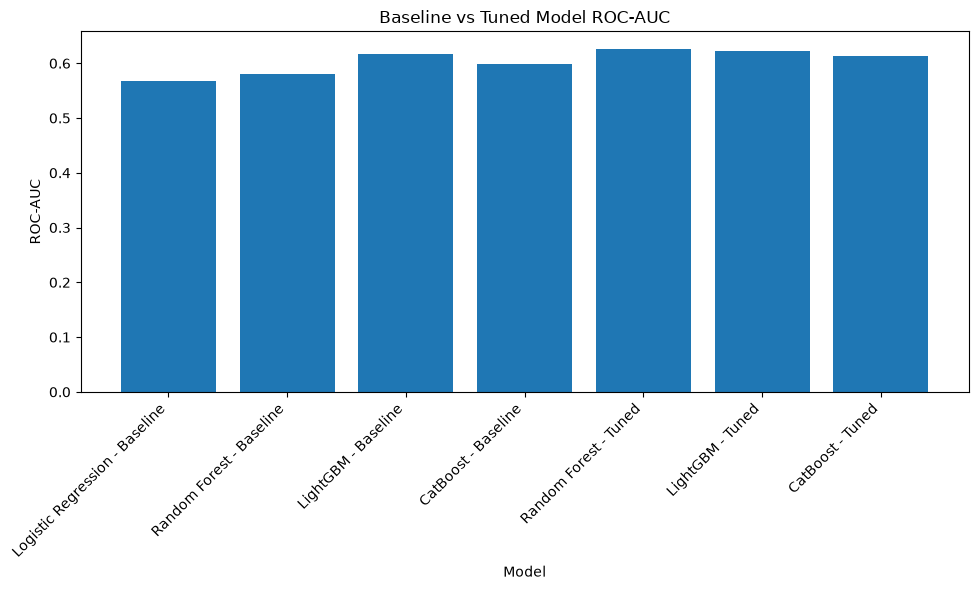

In [64]:
plt.figure(figsize=(10, 6))

plt.bar(
    comparison_results["label"],
    comparison_results["roc_auc"]
)

plt.ylabel("ROC-AUC")
plt.xlabel("Model")
plt.title("Baseline vs Tuned Model ROC-AUC")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Best Model Selection

In [58]:
best_model_row = comparison_results.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
).iloc[0]

print("Best model:")
print(best_model_row)

best_model_name = best_model_row["model"]
best_model_stage = best_model_row["stage"]

print("Model:", best_model_name)
print("Stage:", best_model_stage)
print("F1:", best_model_row["f1_score"])
print("ROC-AUC:", best_model_row["roc_auc"])

Best model:
stage                   Baseline
model                   LightGBM
accuracy                0.584131
precision               0.551904
recall                  0.578548
f1_score                0.564912
roc_auc                 0.616756
label        LightGBM - Baseline
Name: 2, dtype: object
Model: LightGBM
Stage: Baseline
F1: 0.564912089
ROC-AUC: 0.61675551


In [67]:
params = {
    "n_estimators": 300,
    "learning_rate": 0.05,
    "random_state": 42,
    "class_weight": "balanced"
}


baseline_lgbm = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                LGBMClassifier(
                    **params
                )
            )
        ]
    )


baseline_lgbm.fit(
    X_train,
    y_train
)



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['frequency','monetary','avg_order_value',...,'state','latitude', 'longitude']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='p

### Final Model Evaluation

In [82]:
final_model = baseline_lgbm

y_pred = final_model.predict(X_test)
y_prob = final_model.predict_proba(X_test)[:, 1]
print(y_pred)
print(y_prob)

[1 0 1 ... 1 1 0]
[0.51360974 0.44512074 0.53069641 ... 0.56189555 0.61321431 0.4793426 ]


In [83]:
final_metrics = evaluate_model(
    final_model,
    X_test,
    y_test
)

print("Final Model:", best_model_name)

for metric_name, metric_value in final_metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Final Model: LightGBM
accuracy: 0.5841
precision: 0.5519
recall: 0.5785
f1_score: 0.5649
roc_auc: 0.6168


In [84]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Not Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

   Not Churn       0.61      0.59      0.60     10251
       Churn       0.55      0.58      0.56      8969

    accuracy                           0.58     19220
   macro avg       0.58      0.58      0.58     19220
weighted avg       0.59      0.58      0.58     19220



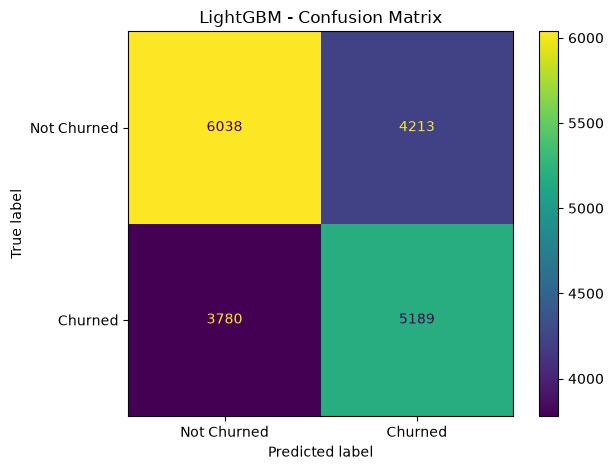

In [85]:
cm = confusion_matrix(
    y_test,
    y_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Churned", "Churned"]
)

disp.plot()
plt.title(f"{best_model_name} - Confusion Matrix")
plt.tight_layout()
plt.show()

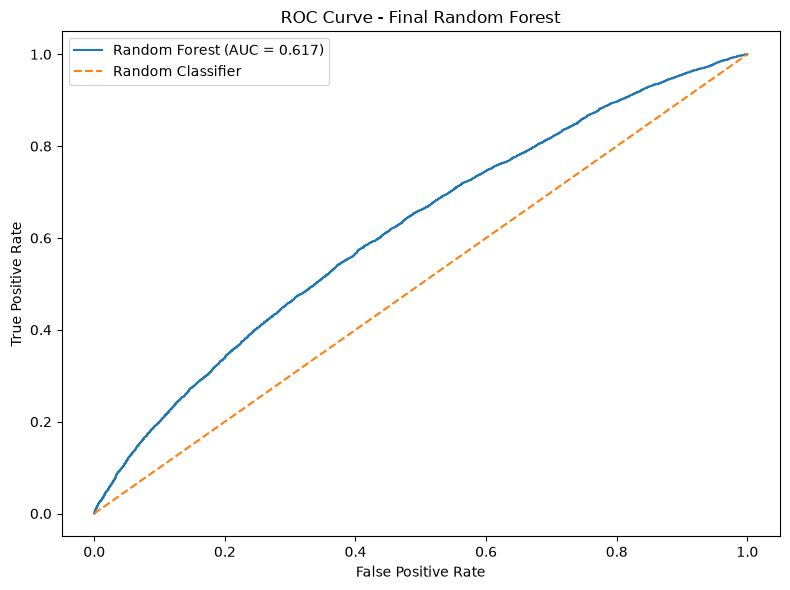

In [81]:
from sklearn.metrics import roc_curve


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {final_metrics['roc_auc']:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [74]:
with mlflow.start_run(run_name="final_model_evaluation"):
    mlflow.log_param(
        "model_type",
        best_model_name
    )

    mlflow.log_param(
        "selection_metric",
        "f1_score"
    )

    mlflow.log_param(
        "secondary_metric",
        "roc_auc"
    )

    for metric_name, metric_value in final_metrics.items():
        mlflow.log_metric(
            metric_name,
            metric_value
        )

    mlflow.sklearn.log_model(
        final_model,
        "final_model",
        serialization_format="pickle"
    )

    print("Final model evaluation logged to MLflow.")

2026/08/09 15:16:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/09 15:16:42 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final model evaluation logged to MLflow.


### Save final model

In [75]:
os.makedirs(
    "../models",
    exist_ok=True
)

joblib.dump(
    final_model,
    "../models/churn_model.pkl"
)

print("Model saved to ../models/churn_model.pkl")

Model saved to ../models/churn_model.pkl
